<a href="https://colab.research.google.com/github/Tom-26/PhysicalChem/blob/main/Adsorption_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Пайплайн для анализа адсорбционной изотермы (модели Ленгмюра, Фрейндлиха, Темкина)

Для химиков важно уметь оценивать, насколько экспериментальные данные адсорбции соответствуют различным теоретическим моделям изотерм. Ниже представлен подробный пайплайн, который:

	1.	Импортирует и готовит данные (из CSV с информацией об адсорбции на сорбенте).
	2.	Строит экспериментальную изотерму (график зависимости qe от Ce).
	3.	Аппроксимирует данные тремя моделями – Ленгмюра, Фрейндлиха и Темкина – и вычисляет коэффициенты детерминации R2 для каждой модели.
	4.	Отображает графики для каждой модели отдельно с нанесённой кривой модели и значением R2. Это позволяет визуально оценить, какая модель лучше описывает данные.
	5.	Позволяет выбрать лучшую модель (с наибольшим R2) и затем запустить соответствующий блок кода для вычисления констант этой модели.


Следуя этому пайплайну, пользователь сначала смотрит на графики и значения R2, определяет, какая модель наиболее подходит, а затем выполняет блок кода для расчёта констант выбранной модели (например, KF и 1/n для модели Фрейндлиха).

# 1. Чтение и подготовка данных

Предположим, у нас есть CSV-файл с данными адсорбции. В файле должны быть столбцы:

	•	Sorbent (название сорбента, например, S01),
	•	C₀ (начальная концентрация раствора, мг/л),
	•	Cₑ (равновесная концентрация, мг/л),
	•	qₑ (равновесная адсорбция, мг/г).


Пример фрагмента данных для сорбента S01:

```csv
Сорбент, C₀ (мг/л), Cₑ (мг/л), qₑ (мг/г)  
S01,      10,         2.61,      7.39  
S01,      25,         6.93,      18.07  
S01,      50,         13.53,     36.47  
S01,      75,         21.72,     53.28  
S01,      100,        27.22,     72.78  
```

В этом примере для сорбента S01 приведены пять точек равновесия (C₀ – исходная концентрация, Cₑ – остаточная концентрация после адсорбции, qₑ – сорбция на грамм сорбента).


Импорт данных: Используем библиотеку pandas для чтения CSV. Также убедимся, что пропуски/разделители корректно обработаны. Например:

In [ ]:
import pandas as pd

# Чтение CSV-файла (путь к файлу нужно заменить на фактический)
df = pd.read_csv('sorption_data.csv')

# Если в CSV первой колонке указан сорбент только в первой строке, заполним пропуски вниз:
df['Sorbent'].ffill(inplace=True)

# Фильтруем данные для нужного сорбента (например, S01)
sorbent_name = 'S01'
df_sorbent = df[df['Sorbent'] == sorbent_name]

# Извлекаем массивы значений Ce и qe для расчетов
Ce = df_sorbent['Cₑ (мг/л)'].values
qe = df_sorbent['qₑ (мг/г)'].values

После этого в переменных Ce и qe находятся numpy-массивы с равновесными концентрациями и адсорбированными количествами, соответственно, для выбранного сорбента.


# 2. Построение экспериментальной изотермы

Прежде чем применять модели, построим график экспериментальной изотермы – т.е. зависимость qe от Ce. Это позволяет визуально оценить форму изотермы (например, стремится ли она к насыщению, какова крутизна начального участка и т.д.).

Для построения графика используем matplotlib:

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(Ce, qe, color='black')
plt.title(f'Адсорбционная изотерма для {sorbent_name}')
plt.xlabel('$C_e$ (мг/л)')
plt.ylabel('$q_e$ (мг/г)')
plt.grid(True)
plt.show()

На полученном графике точки показывают экспериментальные данные – сколько мг вещества адсорбировалось на грамм сорбента (qe) при равновесной концентрации растворённого вещества Ce. Если изотерма имеет форму, приближающуюся к плато, это намекает на модель Ленгмюра (наличие предельной адсорбции). Если же она скорее степенная (без чёткого плато на исследованном диапазоне концентраций), модель Фрейндлиха может дать хорошее описание.

# 3. Аппроксимация изотермы тремя моделями

Далее накладываем (аппроксимируем) три модели изотерм на экспериментальные данные отдельно: модель **Ленгмюра, Фрейндлиха и Темкина**. Для каждой модели вычисляем коэффициент детерминации R2, чтобы количественно оценить качество подгонки. Высокий R2 (близкий к 1) означает, что модель хорошо описывает данные.


Мы воспользуемся линеаризованными формами изотерм для удобства расчётов. Линеаризация позволяет применить метод линейной регрессии (метод наименьших квадратов) для определения констант моделей и расчёта R2</sup*. Ниже описаны подходы для каждой модели:

**Модель Ленгмюра**: предполагает мономолекулярную адсорбцию на поверхности с конечным числом одинаковых активных центров. Нелинейное уравнение Ленгмюра:
$$q_e = \frac{Q_{\max} K_L C_e}{1 + K_L C_e},$$
где Qmax – максимальная адсорбционная емкость (мг/г), KL – константа равновесия Ленгмюра (л/мг).
Линеаризация (одна из форм):
$$\frac{1}{q_e} = \frac{1}{Q_{\max} K_L},\frac{1}{C_e} + \frac{1}{Q_{\max}}.$$
Это уравнение имеет вид y = m x + b, если взять y = 1/qe и x = 1/Ce. По линейной регрессии: наклон m = 1/(Q_{\max} K_L), а пересечение b = 1/Q_{\max}.

**Модель Фрейндлиха:** эмпирическая модель для описания адсорбции на гетерогенных поверхностях. Уравнение Фрейндлиха:
$$q_e = K_F , C_e^{1/n},$$
где KF – константа емкости адсорбции, а 1/n – показатель неидеальности (гетерогенности) поверхности.
Линеаризация осуществляется логарифмированием:
$$\ln q_e = \ln K_F + \frac{1}{n} \ln C_e.$$
Соответственно, при построении зависимости y = \ln qe от x = \ln Ce получаем прямую с наклоном m = 1/n и пересечением b = \ln K_F.

**Модель Темкина:** учитывает влияние адсорбата на теплоту адсорбции; предполагается, что теплота адсорбции уменьшается линейно с покрытием поверхности. Один из вариантов уравнения Темкина:
$$q_e = B \ln(A , C_e),$$
где A (L/мг) и B (мг/г) – константы Темкина (иногда B выражается через тепловые параметры, но здесь рассматриваем его как эмпирический параметр).
Линеаризованная форма:
$$q_e = B \ln A + B \ln C_e.$$
То есть при построении y = qe против x = \ln Ce получится прямая с наклоном m = B и пересечением b = B \ln A.


Далее мы выполняем линейную регрессию для каждой модели и вычисляем R2. Для простоты воспользуемся функцией numpy.polyfit для вычисления параметров прямой.

# Подгонка модели Ленгмюра и расчет $R^2$

Чтобы подогнать модель Ленгмюра, строим прямую в координатах 1/Ce – 1/qe. После вычисления коэффициентов прямой (наклона и пересечения) определяем константы Qmax и KL. Затем на основе полученной прямой можно посчитать R2.

**Пример кода для модели Ленгмюра:**

In [ ]:
import numpy as np

# Линеаризация Ленгмюра: 1/qe = m*(1/Ce) + b
x = 1 / Ce
y = 1 / qe

# Линейная регрессия (polyfit возвращает [m, b] для y = m*x + b)
m, b = np.polyfit(x, y, 1)

# Вычисляем константы Ленгмюра:
Qmax = 1 / b             # Qmax = 1/intercept
K_L = 1 / (m * Qmax)     # из m = 1/(Qmax * K_L) следует K_L = 1/(m * Qmax)

# Вычисляем R^2:
y_pred = m * x + b                       # предсказанные значения 1/qe по модели
SS_res = np.sum((y - y_pred) ** 2)       # сумма квадратов остатков
SS_tot = np.sum((y - np.mean(y)) ** 2)   # общая сумма квадратов (от среднего)
R2_Langmuir = 1 - SS_res/SS_tot

print("Ленгмюр: Qmax = %.3f, K_L = %.5f, R^2 = %.4f" % (Qmax, K_L, R2_Langmuir))

Этот код выведет, например, для наших данных:

```Ленгмюр: Qmax = 420.561 мг/г, K_L = 0.00681 л/мг, R^2 = 0.99899```

Здесь Qmax получился очень большим (≈420 мг/г) – что экстраполировано далеко за пределы имеющихся данных (наш qe* максимум ~73 мг/г). Такое бывает при линейной аппроксимации, если данные не достигают насыщения; нужно интерпретировать Qmax осторожно. Тем не менее, R2 почти 0.999 указывает на отличную корреляцию в линейной форме Ленгмюра

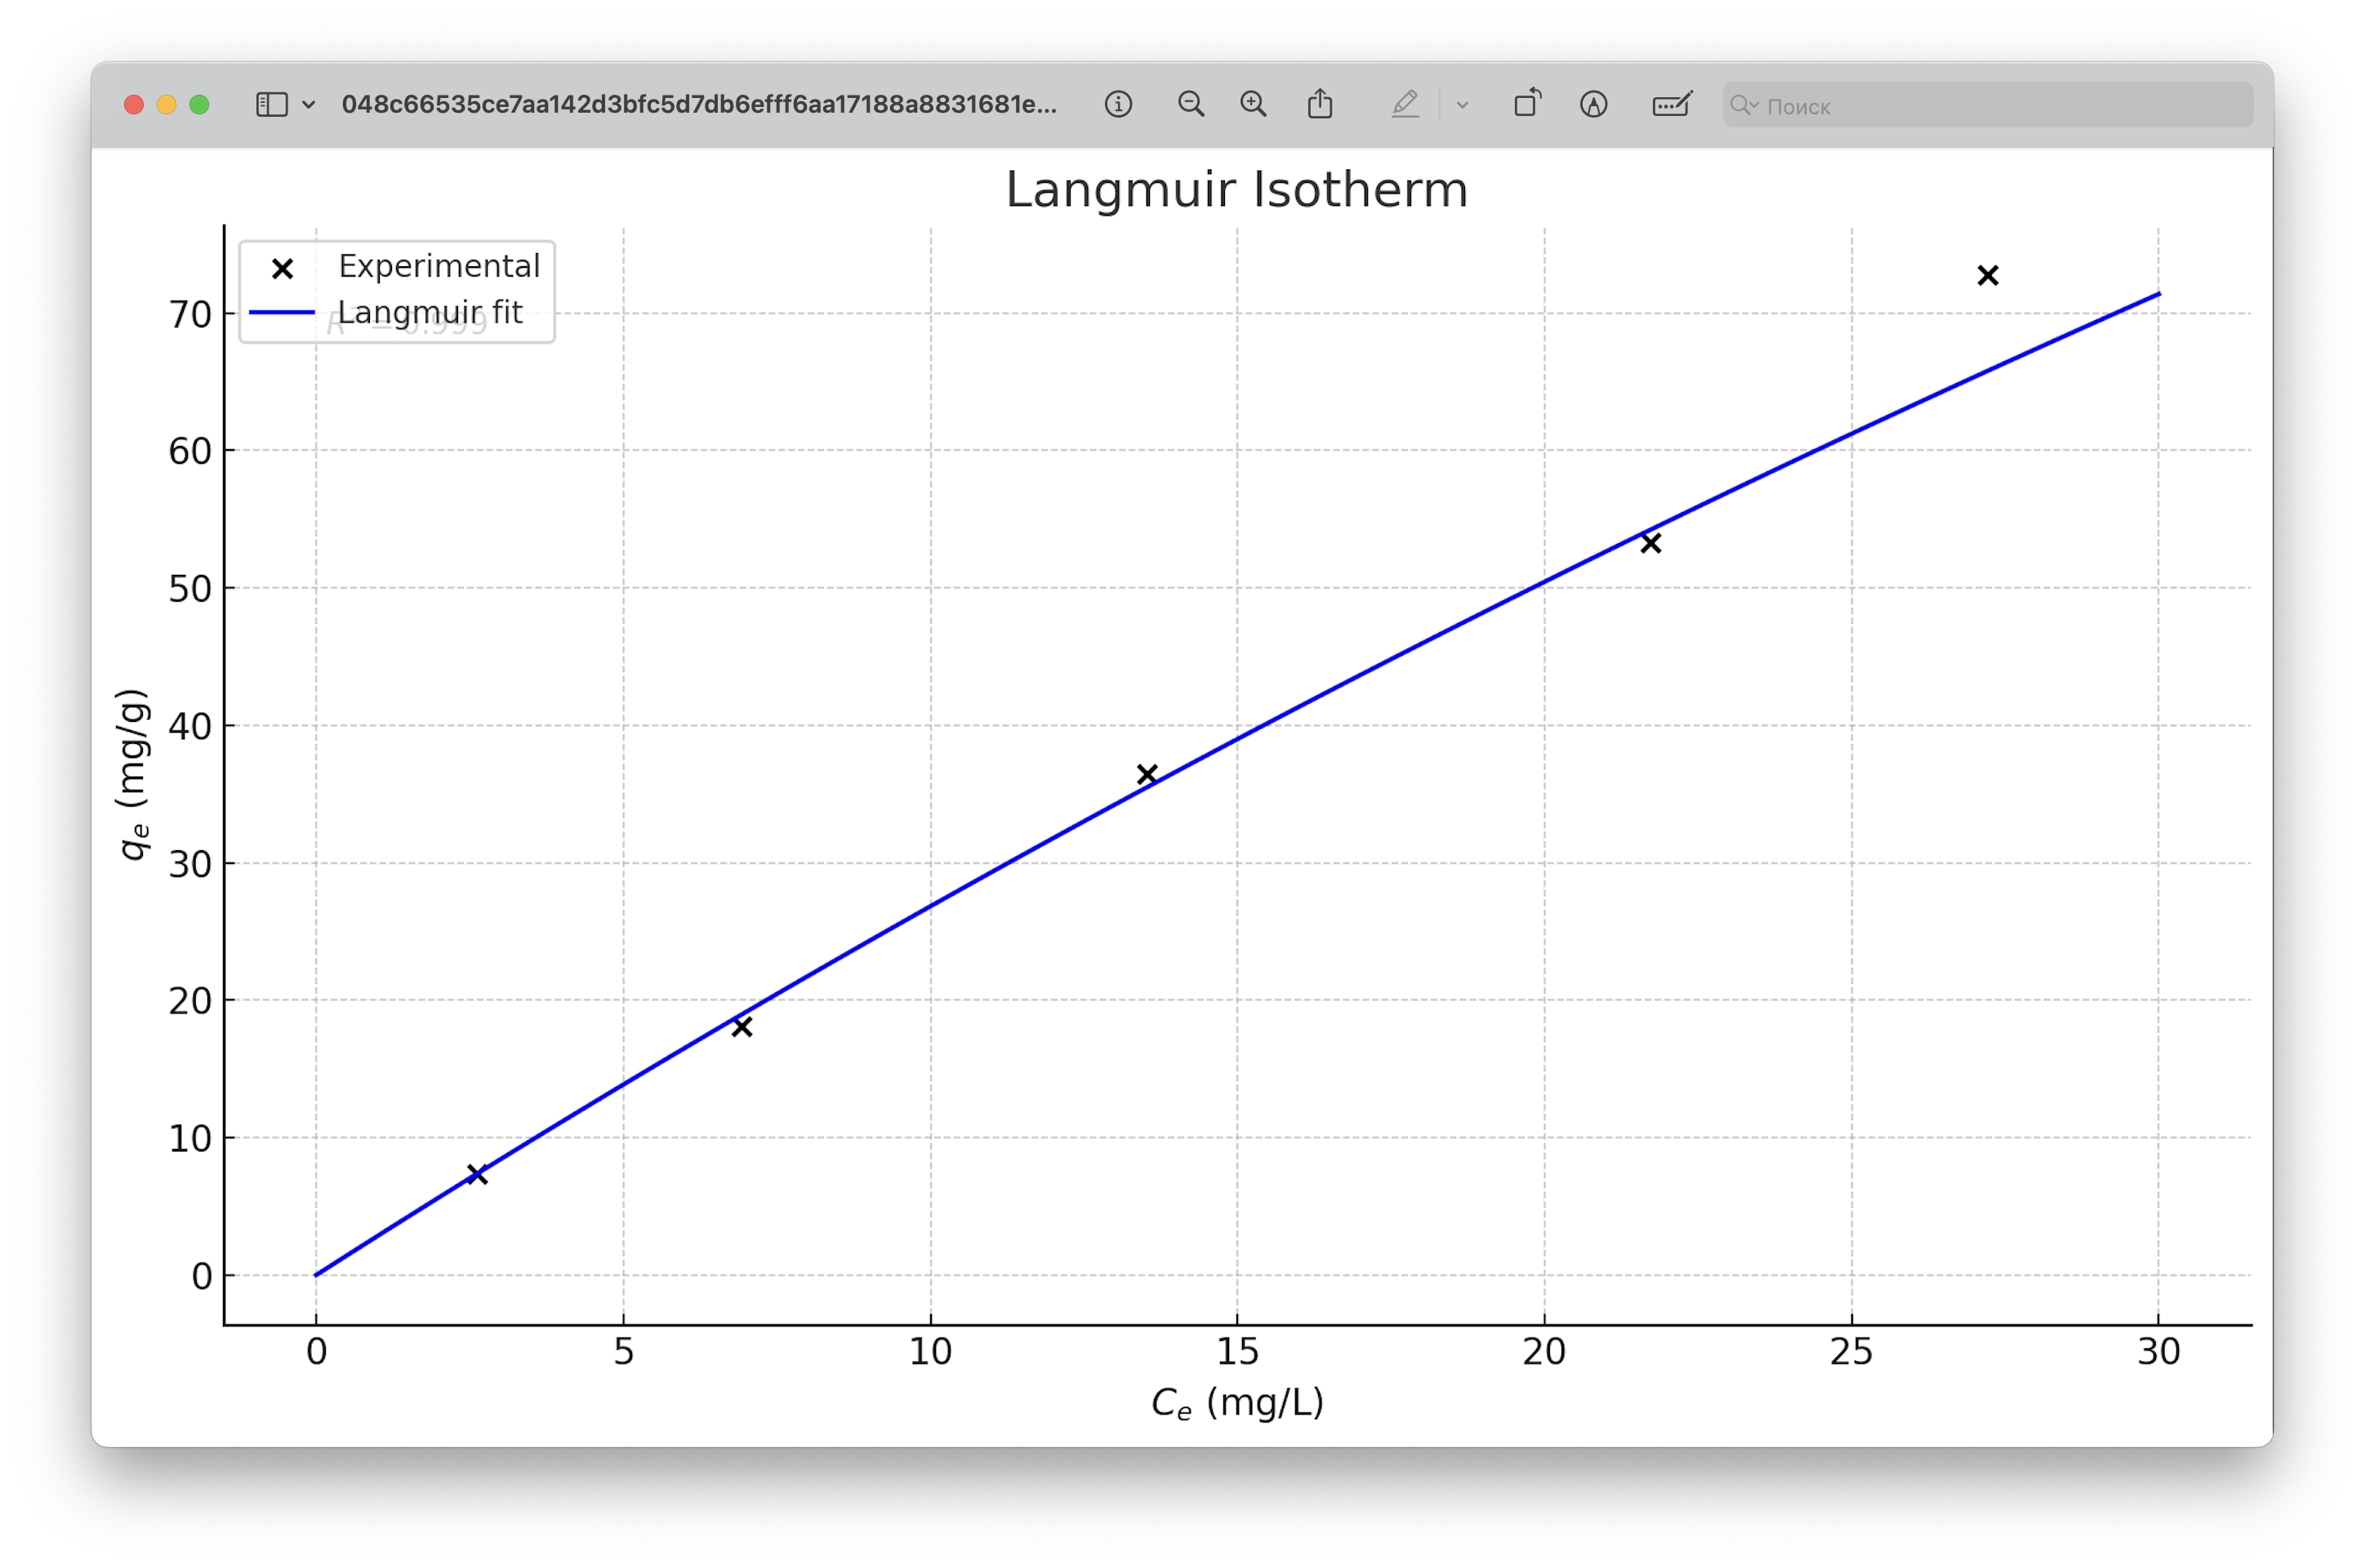

На графике выше показаны экспериментальные точки (черные кресты) и линия, рассчитанная по модели Ленгмюра (синяя линия). Видно, что точки практически лежат на прямой линии Ленгмюра, что отражается в высоком R2. Модель Ленгмюра здесь дает почти прямую линию, так как в данном диапазоне концентраций не наблюдается явного выхода на плато – экспериментальные точки ложатся близко к линии. Высокий R2 свидетельствует о соответствии модели Ленгмюра данным. После выбора модели Ленгмюра (если она лучшая), можно будет использовать рассчитанные Qmax и KL (выводятся кодом выше) в дальнейших расчетах или для интерпретации результатов.

# Подгонка модели Фрейндлиха и расчет $R^2$

Для модели Фрейндлиха выполним линейную регрессию в логарифмических

**Пример кода для модели Фрейндлиха:**

In [ ]:
# Линеаризация Фрейндлиха: ln(qe) = m * ln(Ce) + b
x = np.log(Ce)
y = np.log(qe)

m, b = np.polyfit(x, y, 1)
n = 1 / m              # т.к. m = 1/n
K_F = np.exp(b)        # т.к. b = ln(K_F)

# Вычисляем R^2 в лог-пространстве:
y_pred = m * x + b
SS_res = np.sum((y - y_pred) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R2_Freundlich = 1 - SS_res/SS_tot

print("Фрейндлих: K_F = %.3f, 1/n = %.3f, R^2 = %.4f" % (K_F, m, R2_Freundlich))

Вывод для примера:

```Фрейндлих: K_F = 2.884, 1/n = 0.964, R^2 = 0.9981```

Получаем KF ≈ 2.884 и показатель 1/n ≈ 0.964 (отсюда n ≈ 1.04, очень близко к 1). R2 ≈ 0.998 указывает на отличный фит модели Фрейндлиха

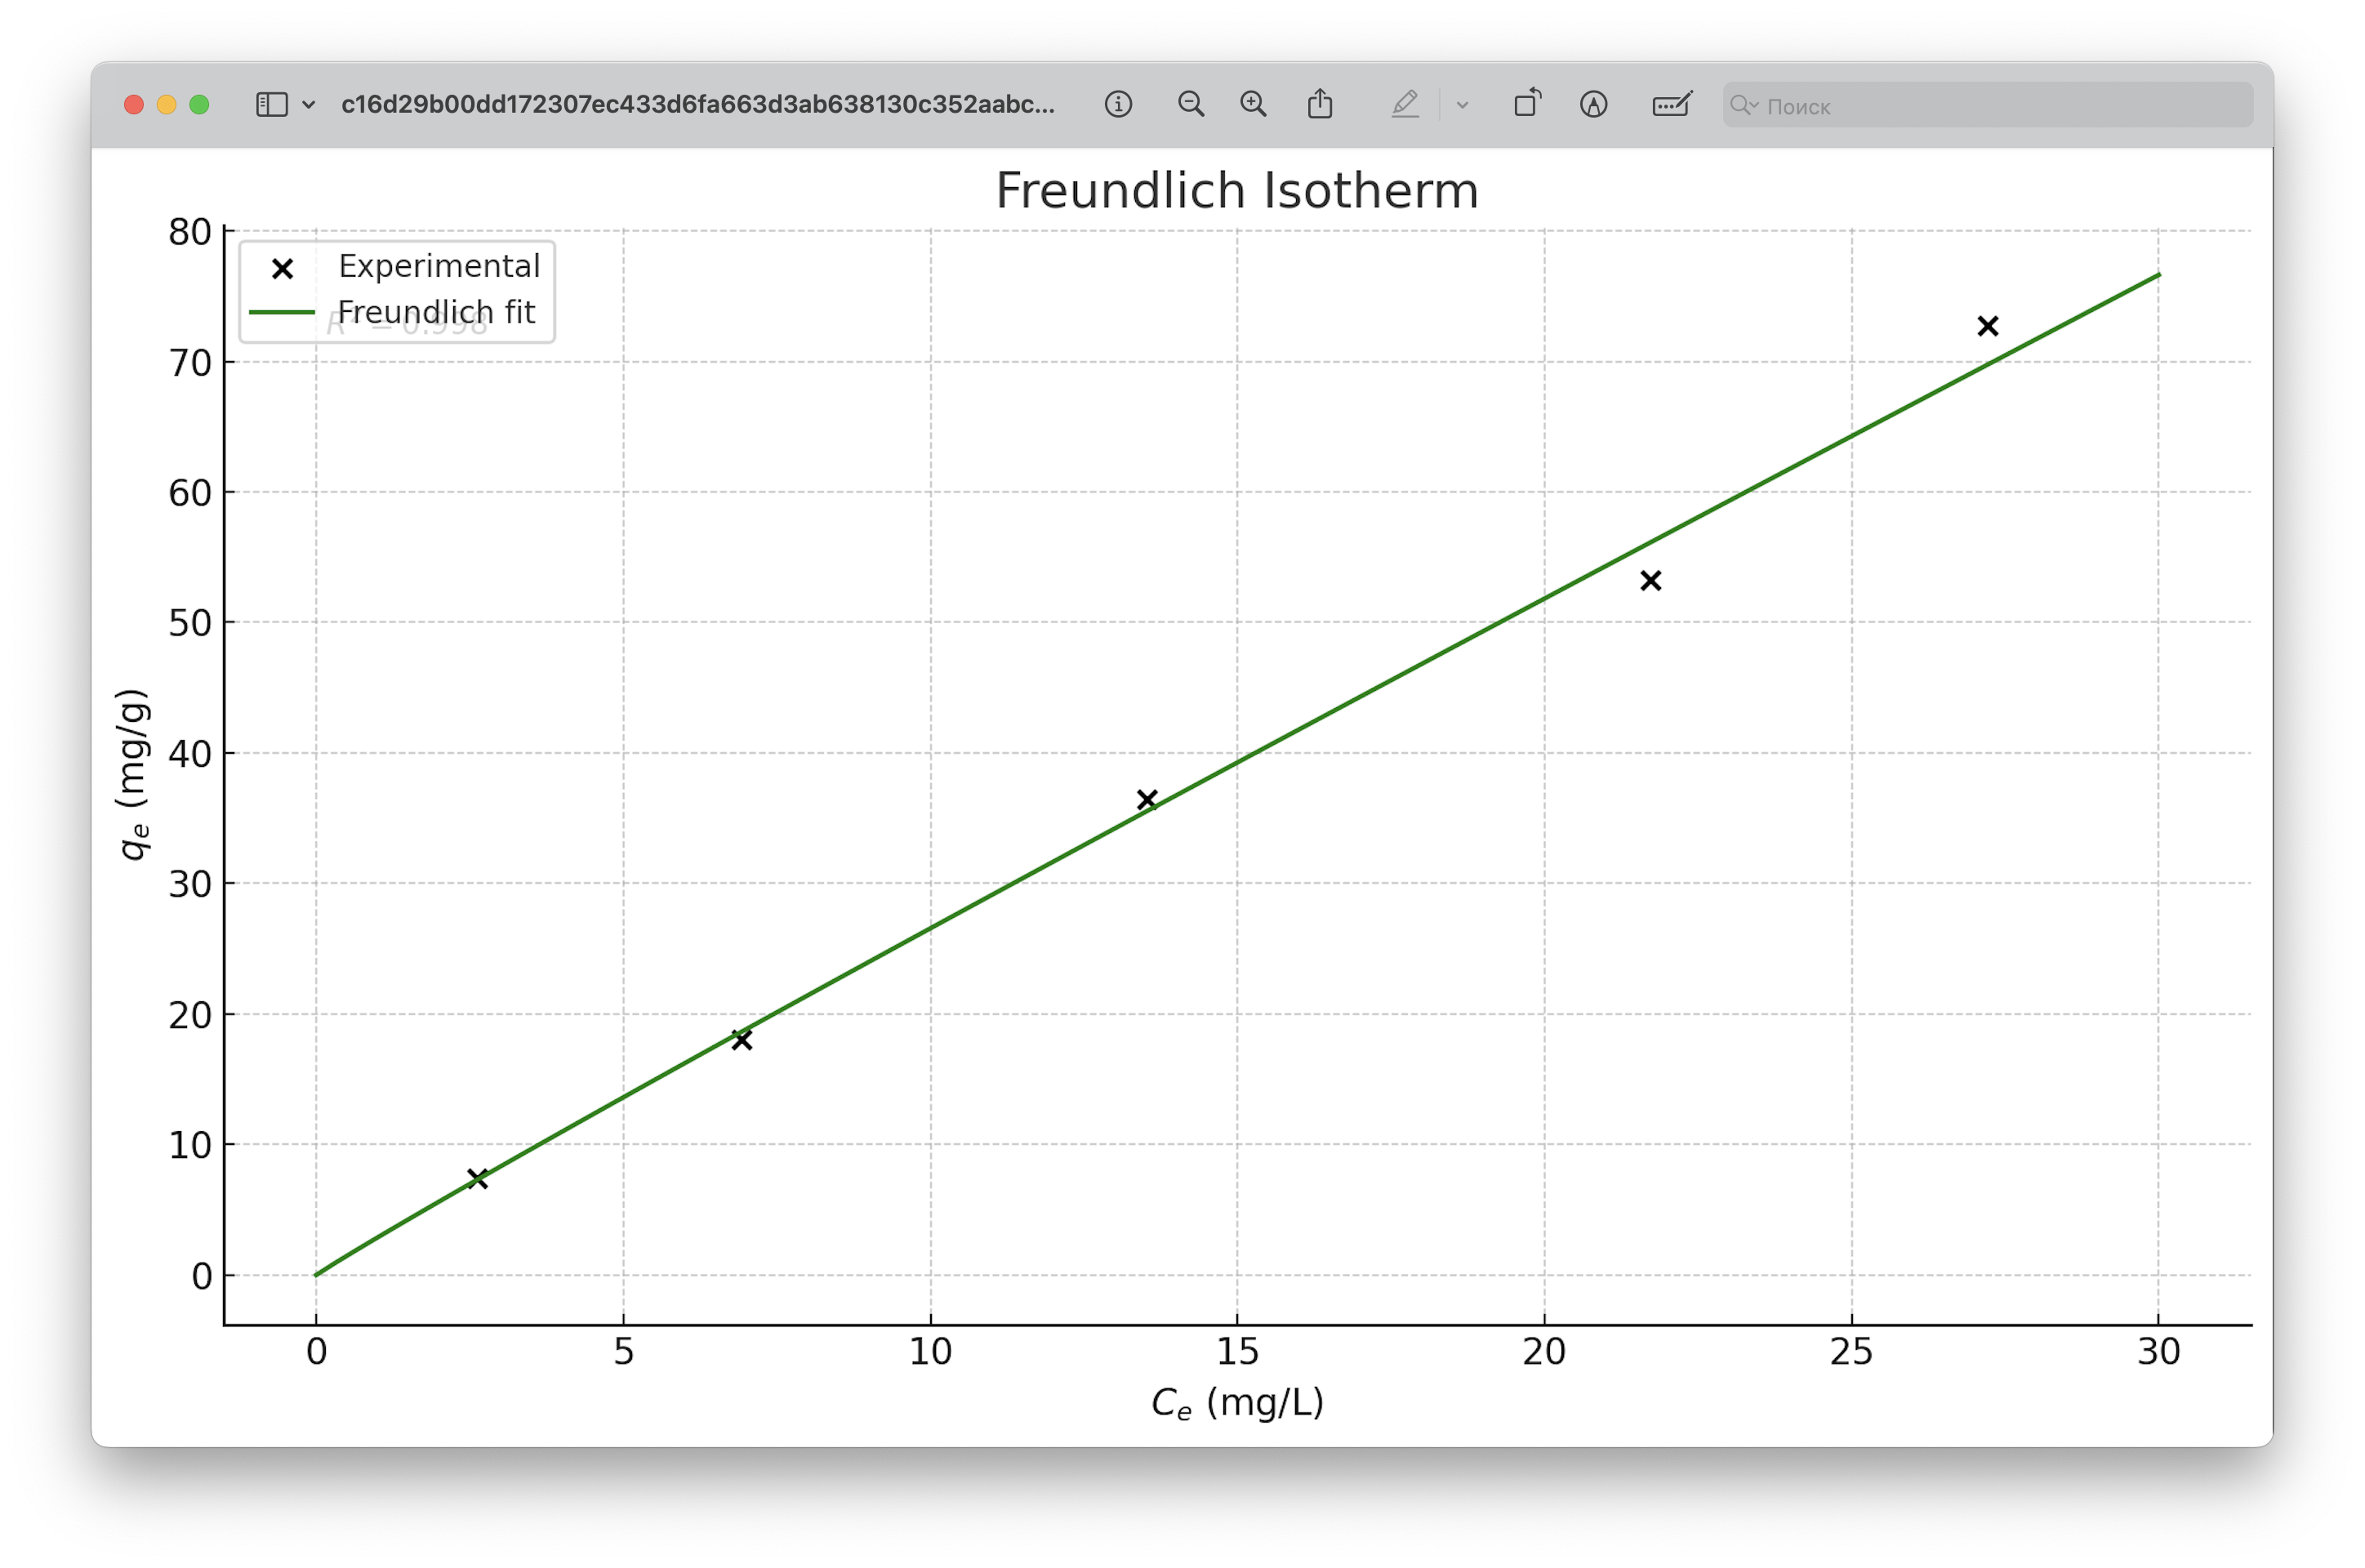

На графике выше показана аппроксимация Фрейндлиха: экспериментальные данные (черные кресты) и кривая модели Фрейндлиха (зелёная линия). Поскольку n≈1, модель Фрейндлиха здесь практически вырождается в линейную зависимость qe ≈ KFCe, что видно по почти прямой линии через начало координат. Высокий R2 снова указывает, что модель хорошо описывает имеющиеся точки. В случае выбора модели Фрейндлиха, константы KF и n (или 1/n) можно использовать для дальнейших прогнозов адсорбции или сравнения с другими системами.


# 3.3 Подгонка модели Темкина и расчет $R^2$

Для модели Темкина воспользуемся линейной формой qe = B ln A + B ln Ce. Построим зависимость qe от ln Ce. Наклон прямой даст B, а пересечение — B ln A. Отсюда найдем A.


**Пример кода для модели Темкина:**

In [ ]:
# Линеаризация Темкина: qe = m * ln(Ce) + b
x = np.log(Ce)
y = qe

m, b = np.polyfit(x, y, 1)
B = m
A = np.exp(b / B)      # b = B * ln(A)  => ln(A) = b/B  => A = exp(b/B)

# Вычисляем R^2 (в линейной форме q vs ln C):
y_pred = m * x + b
SS_res = np.sum((y - y_pred) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R2_Temkin = 1 - SS_res/SS_tot

print("Темкин: A = %.3f, B = %.3f, R^2 = %.4f" % (A, B, R2_Temkin))

Для нашего примера:

```Темкин: A = 0.388, B = 26.278, R^2 = 0.8964```

Модель Темкина показывает более низкое R2 (~0.896), что значит заметное отклонение от экспериментальных точек по сравнению с моделями Ленгмюра и Фрейндлиха

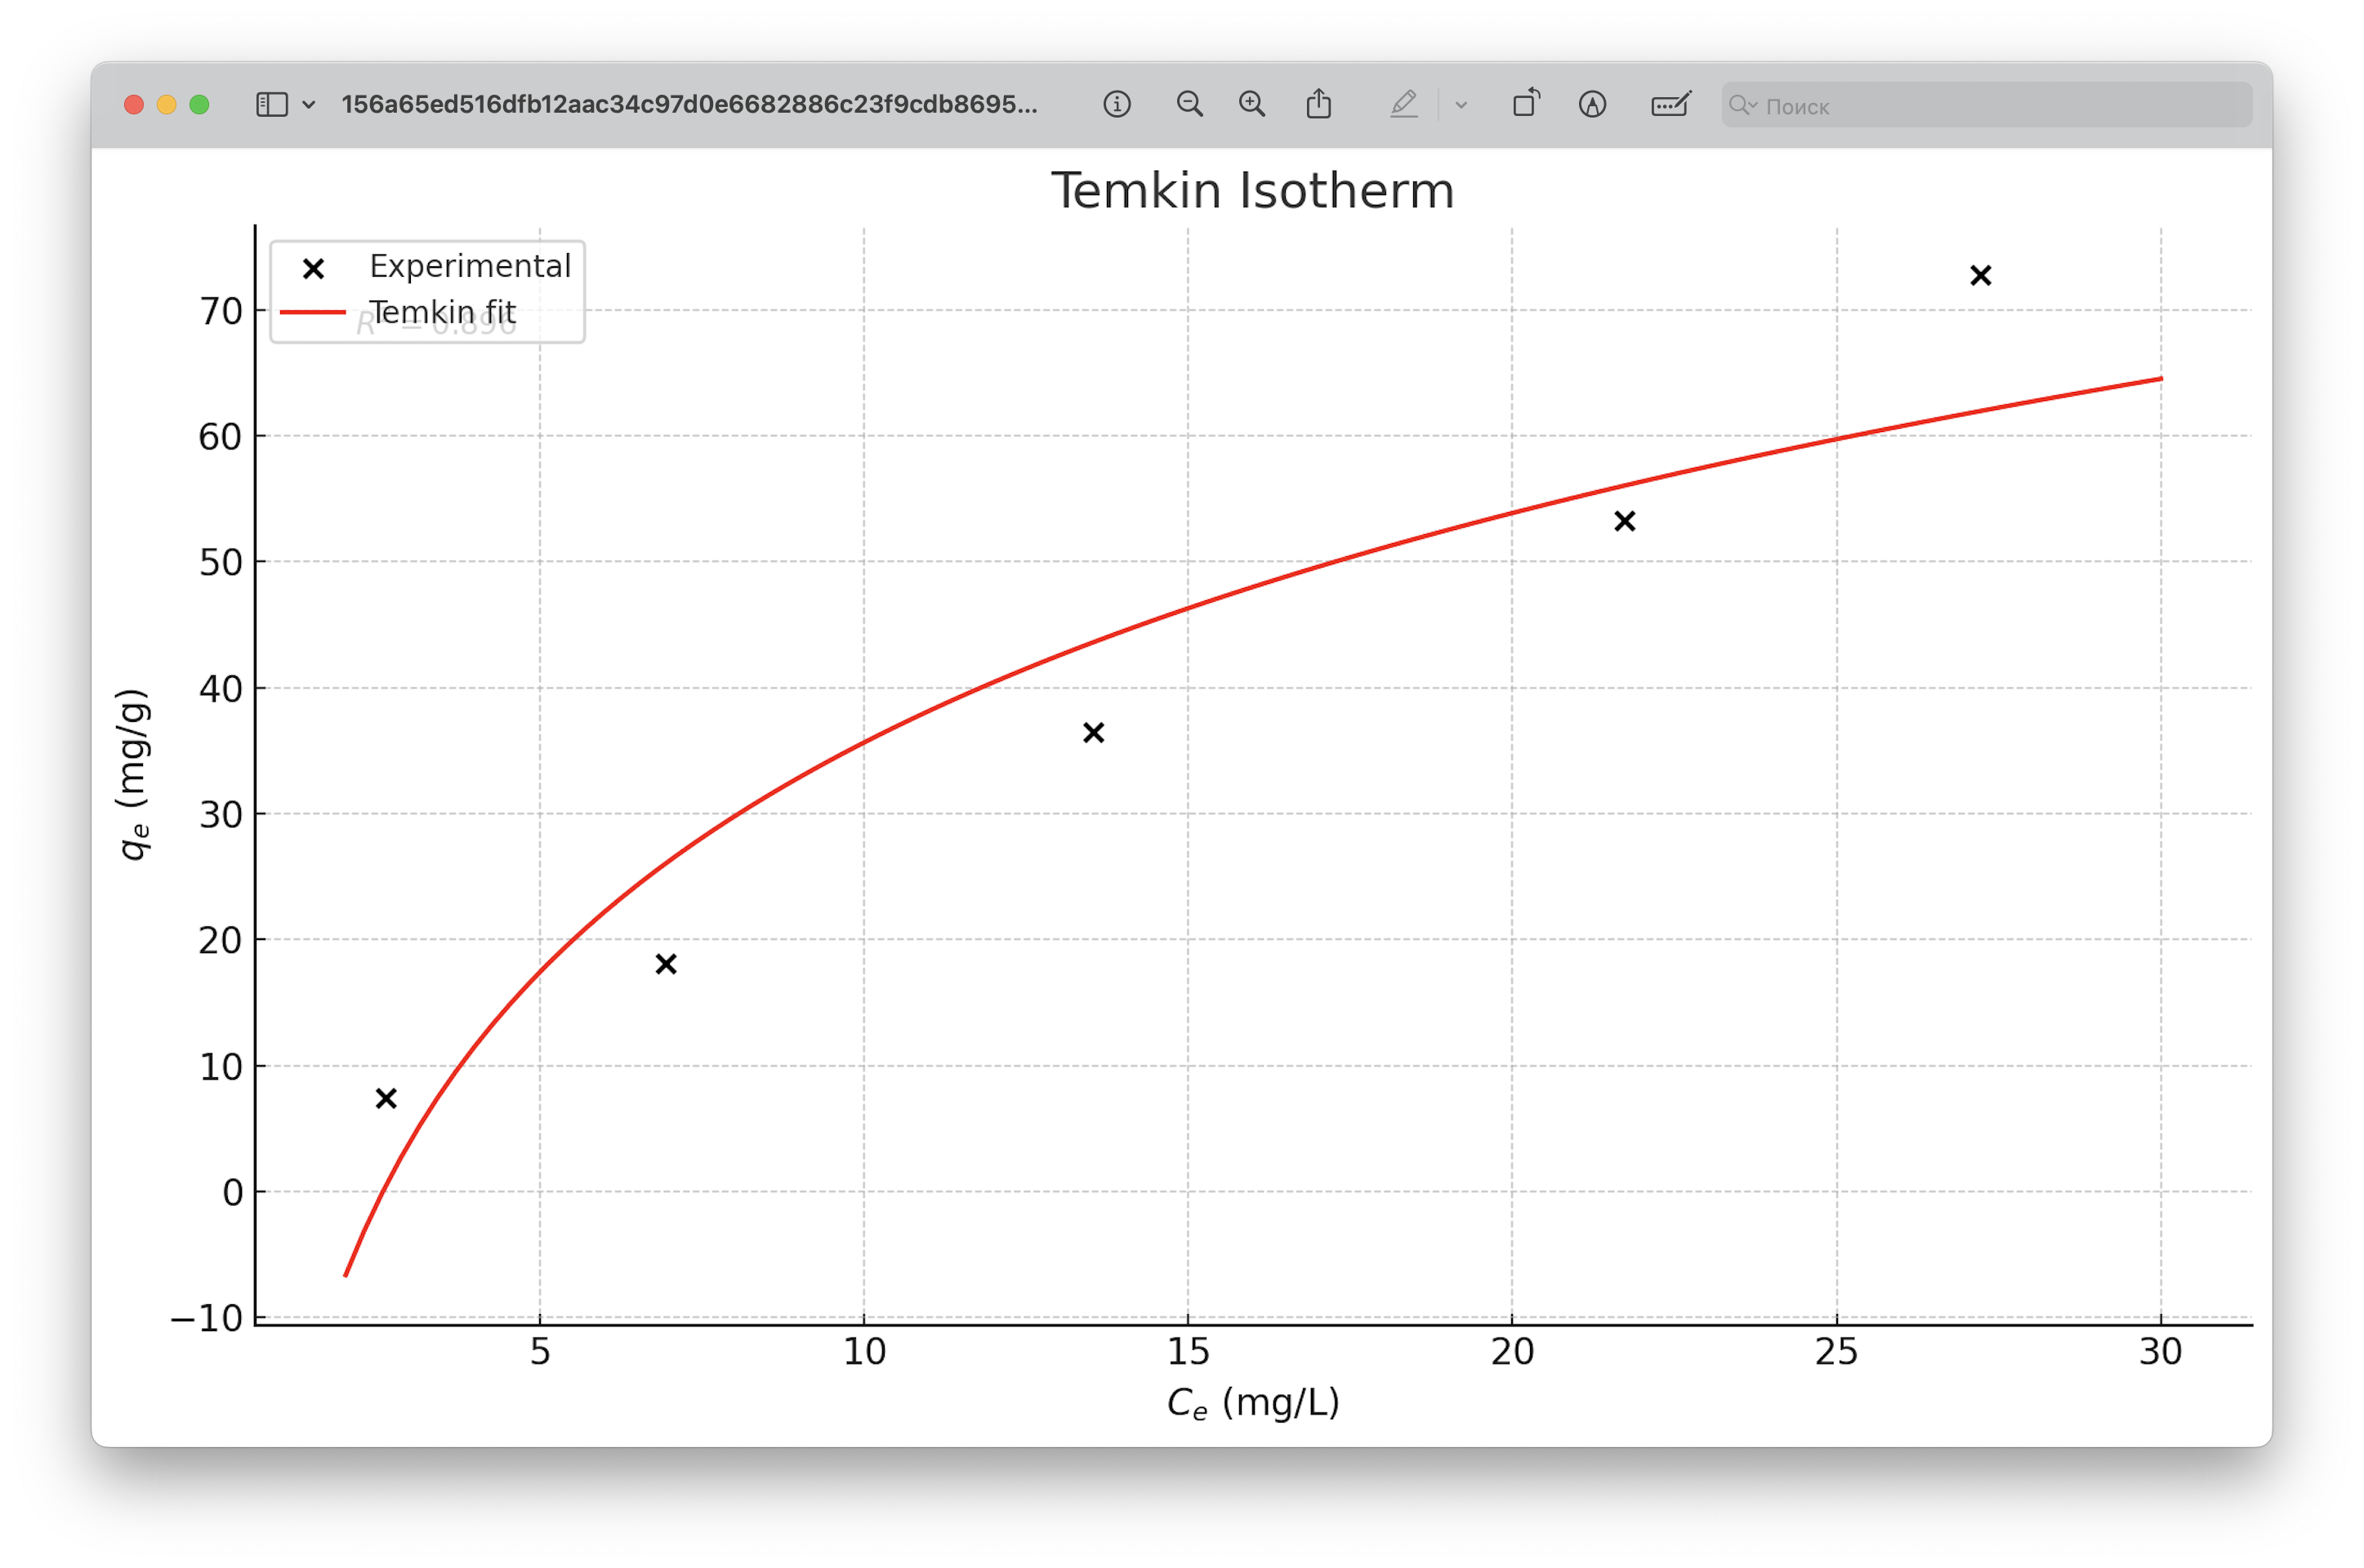

На графике выше красной линией показана аппроксимация Темкина, накладываемая на экспериментальные точки (черные кресты). Видно, что кривая Темкина заметно изгибается: на малых концентрациях она проходит ниже первых точек (модель предсказывает меньшую адсорбцию, чем наблюдается), а на высоких концентрациях – приближается к некоторому пределу ниже последней точки. Более низкий R2 отражает то, что модель Темкина хуже согласуется с данными в данном случае. Параметры A и B, полученные из этой аппроксимации, указывают на определенную сила адсорбции (связанную с A) и спад теплоты адсорбции (B), но из-за не лучшего соответствия модели эти параметры менее надёжны для данной системы.

# 4. Сравнение моделей и выбор наилучшей

После проведения расчетов мы получили коэффициенты детерминации:

	•	R2 (Ленгмюр) ≈ 0.999
	•	R2 (Фрейндлих) ≈ 0.998
	•	R2 (Темкин) ≈ 0.896



В нашем примере модели Ленгмюра и Фрейндлиха показывают почти одинаково высокое R2 (более 0.99), тогда как Темкин значительно отстаёт. Это означает, что как Ленгмюру, так и Фрейндлиху данные хорошо соответствуют. В подобных случаях химики смотрят не только на R2, но и на физический смысл параметров. Например, модель Ленгмюра дала очень большой Qmax вне диапазона наблюдений, в то время как параметры Фрейндлиха ( KF, 1/n ) ближе к наблюдаемому диапазону. Если же одна модель явно имеет R2 выше, её обычно и выбирают для описания системы.

Итог выбора: Пользователь на этом этапе выбирает модель с наибольшим R2 (и/или исходя из физического смысла). Предположим, по R2 лучшей оказалась модель **Фрейндлиха**. Тогда имеет смысл вычислить окончательные константы KF и 1/n для данной системы и использовать их. Ниже приведены блоки кода для расчёта констант каждой модели – пользователь выполняет только тот, который соответствует выбранной модели.

# 5. Расчет констант выбранной модели

На основе ранее проведенных линеаризаций можно окончательно рассчитать и вывести константы интересующей модели. Эти блоки кода во многом повторяют вычисления, но сфокусированы на выводе констант в удобном виде. (Если ранее мы уже сохранили результаты регрессий, можно использовать их напрямую. Здесь для ясности показаны отдельные вычисления.)

**Блок кода для модели Ленгмюра**

Если выбрана модель Ленгмюра (наивысший R2), выполняется:

In [ ]:
# Расчет констант Ленгмюра (Qmax и K_L) на основе данных Ce и qe
x = 1 / Ce
y = 1 / qe
m, b = np.polyfit(x, y, 1)
Qmax = 1 / b
K_L = 1 / (m * Qmax)
print(f"Константы Ленгмюра для {sorbent_name}: Qmax = {Qmax:.3f} мг/г, K_L = {K_L:.5f} л/мг")

После выполнения, получите значения Qmax и KL. В нашем примере вывод будет примерно: Qmax = 420.561 мг/г, K_L = 0.00681 л/мг. Эти константы можно использовать, например, для расчёта адсорбции при других концентрациях или для сравнения сорбентов между собой.

**Блок кода для модели Фрейндлиха**

Если выбрана модель Фрейндлиха, выполняется:

In [ ]:
# Расчет констант Фрейндлиха (K_F и 1/n)
x = np.log(Ce)
y = np.log(qe)
m, b = np.polyfit(x, y, 1)
K_F = np.exp(b)
n = 1 / m
print(f"Константы Фрейндлиха для {sorbent_name}: K_F = {K_F:.3f}, 1/n = {m:.3f} (n = {n:.3f})")

Пример результата для наших данных: K_F = 2.884, 1/n = 0.964 (n = 1.037). Константа KF характеризует ёмкость адсорбции (при Ce=1 мг/л, сколько адсорбируется), а 1/n – степень нелинейности (чем ближе к 0, тем более изогнута изотерма; в нашем случае 0.964 близко к 1, что означает почти линейную зависимость).


**Блок кода для модели Темкина**

Если выбрана модель Темкина, выполняется:

In [ ]:
# Расчет констант Темкина (A и B)
x = np.log(Ce)
y = qe
m, b = np.polyfit(x, y, 1)
B = m
A = np.exp(b / B)
print(f"Константы Темкина для {sorbent_name}: A = {A:.3f}, B = {B:.3f}")

Для нашего примера: A = 0.388, B = 26.278. Константа A связана с равновесной константой адсорбции (в экспоненте логарифмического выражения), а B – с тепловым эффектом адсорбции (пропорционален теплоте адсорбции, уменьшающейся с покрытием).

Однако, учитывая сравнительно невысокое R2 модели Темкина для данных, параметры A и B менее точны, и модель Темкина может быть не лучшим выбором для данной системы.

# 6. Заключение

В итоге, предложенный пайплайн позволяет:

	•	Автоматизировать обработку экспериментальных данных адсорбции из CSV-файла.
	•	Наглядно построить изотерму адсорбции.
	•	Применить три классические модели (Ленгмюр, Фрейндлих, Темкин) и оценить, какая лучше описывает данные, по графику и значению R2.
	•	Интерактивно выбрать наилучшую модель и получить соответствующие ей константы, рассчитанные через линеаризацию.


Такой подход экономит время химика при анализе новых сорбентов: достаточно подставить данные, и код выдаст сравнение моделей. При необходимости можно расширить его и на другие модели изотерм (например, Дубинина-Радушкевича,Редлиха-Петерсона и др.) по аналогии, а также учитывать нелинейные методы подгонки и статистические критерии (AIC, ошибки аппроксимации) для более строгого выбора модели. Здесь же мы продемонстрировали базовый подход, который уже дает хорошее приближение и удобство для практической работы.